## Basic Fitting for Qubit Scan Data

Based on 
https://doi.org/10.1103/PhysRevApplied.13.024066

In [2]:
# Packages and Data Loading
# directly loaded raw data as we need complex s21 data
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

with open("28-09-2026/1790628601-vna-power-sweep.json", "r") as f:
    qubit_power_scan = json.load(f)

with open("28-09-2026/1790630661-vna-power-sweep.json", "r") as f:
    no_qubit_power_scan = json.load(f)

s_real_qubit = np.asarray(qubit_power_scan['s_real'])
s_imag_qubit = np.asarray(qubit_power_scan['s_imag'])
s_complex_qubit = s_real_qubit + 1j * s_imag_qubit

s_real_no_qubit = np.asarray(no_qubit_power_scan['s_real'])
s_imag_no_qubit = np.asarray(no_qubit_power_scan['s_imag'])
s_complex_no_qubit = s_real_no_qubit + 1j * s_imag_no_qubit

s_qubit_avg = np.mean(s_complex_qubit, axis=1)
s_no_qubit_avg = np.mean(s_complex_no_qubit, axis=1)

normalized_transmission = s_qubit_avg / s_no_qubit_avg
normalized_reflection = 1 - normalized_transmission
re_r = normalized_reflection.real

frequencies = np.asarray(qubit_power_scan["fghz"])
powers = np.asarray(qubit_power_scan["power"])



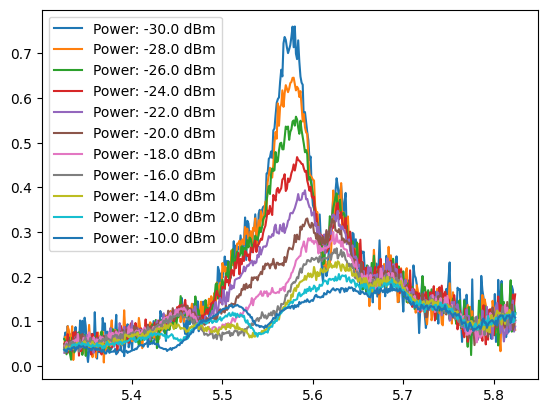

In [26]:
# Quick Check of Data
a = 0
b = 400
for i in range(0,len(powers),2):
    plt.plot(frequencies[a:b], abs(normalized_reflection[i][a:b]), label=f'Power: {powers[i]} dBm')
plt.legend()
plt.show()

## Find Gamma1, Gamma2

Fit all data at once.  
applied frequency mask.  
Fano interference is not considered yet. maybe good one to try soon.

f0 = 5.5798716 GHz
Gamma1/(2π) = 23.0822 MHz
Gamma2/(2π) = 13.1877 MHz
Omega_ref/(2π) = 9.6619 MHz
Background = 0.06099


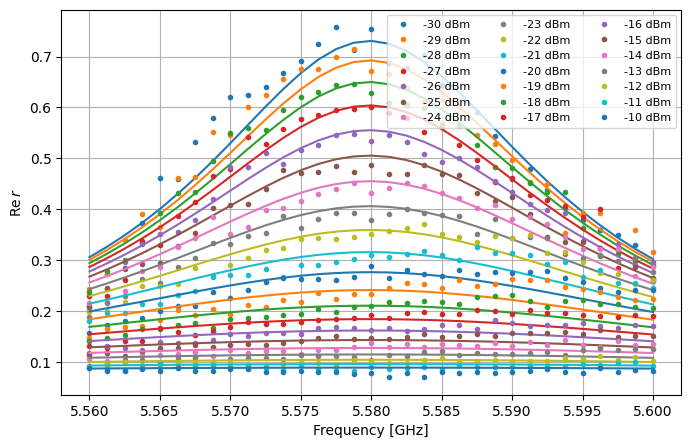

In [ ]:
# fit model and extract g1 g2

# eq. 3
def reflection_model(f, f0, g1, g2, omega):
    df = (f - f0) * 1000  # MHz
    a = g1 / (2 * g2)
    b = 1 + 1j * df / g2
    c = 1 + (df / g2)**2 + omega**2 / (g1 * g2)
    return a * b / c


# fit all power data at once using omega_ref. add background for better fitting (we need better normalization)
def fit_model(x, f0, g1, g2, omega_ref, background):
    f, p = x
    omega = omega_ref * 10**((p - P_ref) / 20)
    return reflection_model(f, f0, g1, g2, omega).real + background


# fitting range
f_min, f_max = 5.56, 5.60  # GHz
P_ref = -30.0             # dBm. just reference power on vna output for fitting.

fmask = (frequencies >= f_min) & (frequencies <= f_max)
F, P = np.meshgrid(frequencies[fmask], powers)
fit_s = re_r[:, fmask]

p0 = [5.58, 20.0, 10.0, 9.0, 0.0]

popt, pcov = curve_fit(
    fit_model,
    (F.ravel(), P.ravel()),
    fit_s.ravel(),
    p0=p0,
    bounds=(
        [f_min, 1, 1, 0.0, -0.3],
        [f_max, 100., 100., 200., 0.3],
    ),
    x_scale="jac",
    max_nfev=30000,
)

f0_fit, g1_fit, g2_fit, omega_ref_fit, b0_fit = popt

print(f"f0 = {f0_fit:.7f} GHz")
print(f"Gamma1/(2π) = {g1_fit:.4f} MHz")
print(f"Gamma2/(2π) = {g2_fit:.4f} MHz")
print(f"Omega_ref/(2π) = {omega_ref_fit:.4f} MHz")
print(f"Background = {b0_fit:.5f}")


plt.figure(figsize=(8, 5))

for i, p in enumerate(powers):
    line, = plt.plot(
        frequencies[fmask], fit_s[i],
        ".", label=f"{p:g} dBm"
    )
    fitted = fit_model(
        (frequencies[fmask], np.full(F.shape[1], p)),
        *popt
    )
    plt.plot(frequencies[fmask], fitted, color=line.get_color())

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"$\mathrm{Re}\,r$")
plt.legend(ncol=3, fontsize=8)
plt.grid()
plt.show()

## Get Attenuation

get W0 from gamma1 and gamma2 using eq.(4)  
do linear fitting to Win vs W0 where slop is attenuation.

Input attenuation = 103.55 dB


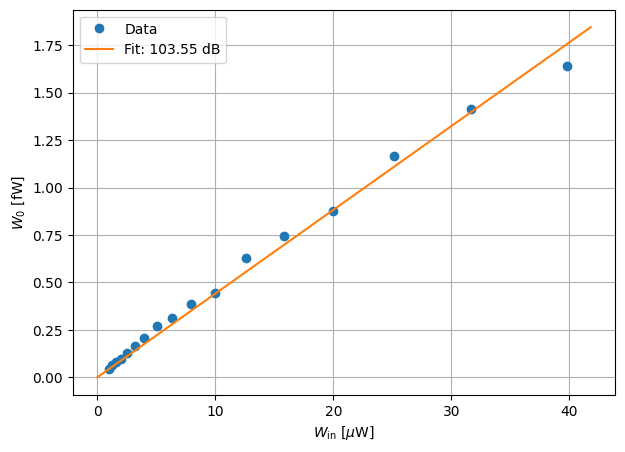

In [ ]:
P_fit_max = -14.0
h = 6.62607015e-34 

# Convert unit
gamma1 = 2 * np.pi * g1_fit * 1e6
gamma2 = 2 * np.pi * g2_fit * 1e6

# Reflection at resonance, with constant background removed
r_on = np.array([
    np.interp(f0_fit, frequencies, row)
    for row in re_r
]) - b0_fit

# eq. 4
Win = 1e-3 * 10**(powers / 10)
W0 = (gamma1 / (4 * r_on) - gamma2 / 2) * h * f0_fit * 1e9

mask = powers <= P_fit_max
x = Win[mask] / 1e-6    # uW
y = W0[mask] / 1e-15    # fW

# Fit y = slope * x
slope = np.dot(x, y) / np.dot(x, x)
attenuation_slope_db = -10 * np.log10(slope * 1e-9)

print(f"Input attenuation = {attenuation_slope_db:.2f} dB")

plt.figure(figsize=(7, 5))
plt.plot(x, y, "o", label="Data")

x_line = np.linspace(0, x.max() * 1.05, 100)
plt.plot(
    x_line, slope * x_line,
    label=f"Fit: {attenuation_slope_db:.2f} dB"
)

plt.xlabel(r"$W_{\mathrm{in}}$ [$\mu$W]")
plt.ylabel(r"$W_0$ [fW]")
plt.legend()
plt.grid()
plt.show()